<a href="https://colab.research.google.com/github/hansadisr/uber-fare-prediction/blob/main/Uber_Fare_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title: Uber Fare Prediction

In [ ]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

**Data Exploration**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving uber.csv.zip to uber.csv (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile('uber.csv (1).zip','r') as zip_ref:
    zip_ref.extractall()

In [ ]:
#Load Dataset
df = pd.read_csv("uber.csv")
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


**Dataset Overview**

In [ ]:
df.shape

(200000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [ ]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [ ]:
# check missing values
df.isnull().sum()

,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,1
dropoff_latitude,1
passenger_count,0


**Data Cleaning**

In [ ]:
# Remove Missing Values
df = df.dropna()

In [ ]:
#Remove invalid values
df = df[(df['fare_amount'] > 0) & (df['passenger_count'] > 0)]

**Feature Enginnering**

In [ ]:
# Convert Datatime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [ ]:
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month

**Distance Calculation**

In [ ]:
from math import radians, cos, sin, asin, sqrt

def haversine(lon1, lat1, lon2, lat2):

    lon1, lat1, lon2, lat2 = map(radians,[lon1,lat1,lon2,lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2*asin(sqrt(a))

    r = 6371
    return c*r

df['distance_km'] = df.apply(lambda row: haversine(
    row['pickup_longitude'],
    row['pickup_latitude'],
    row['dropoff_longitude'],
    row['dropoff_latitude']),axis=1)

**Exploratory Data Analysis**

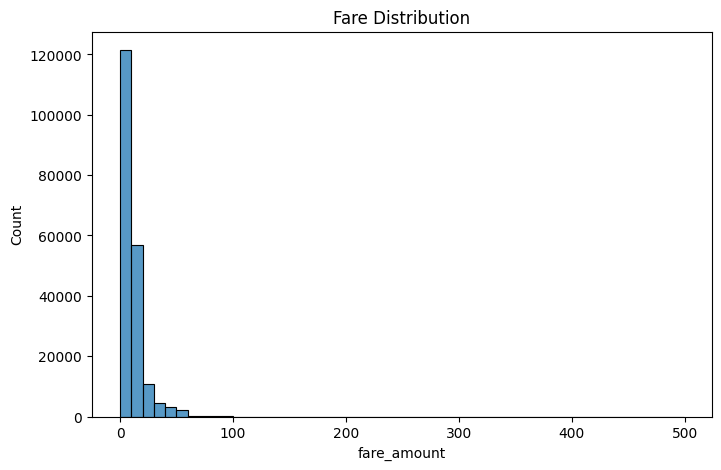

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['fare_amount'], bins=50)
plt.title("Fare Distribution")
plt.show()

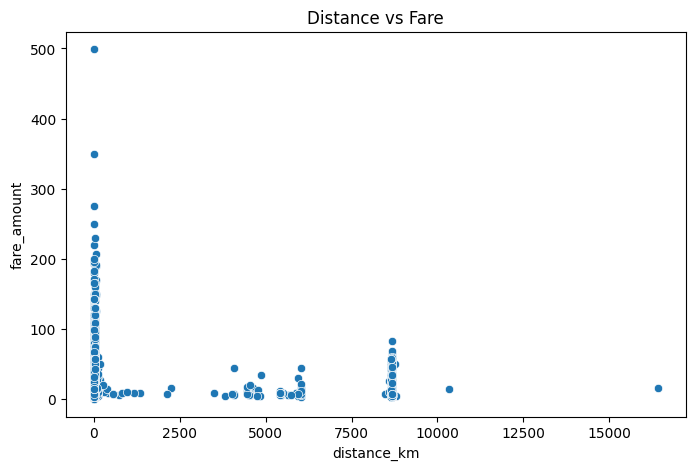

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['distance_km'], y=df['fare_amount'])
plt.title("Distance vs Fare")
plt.show()

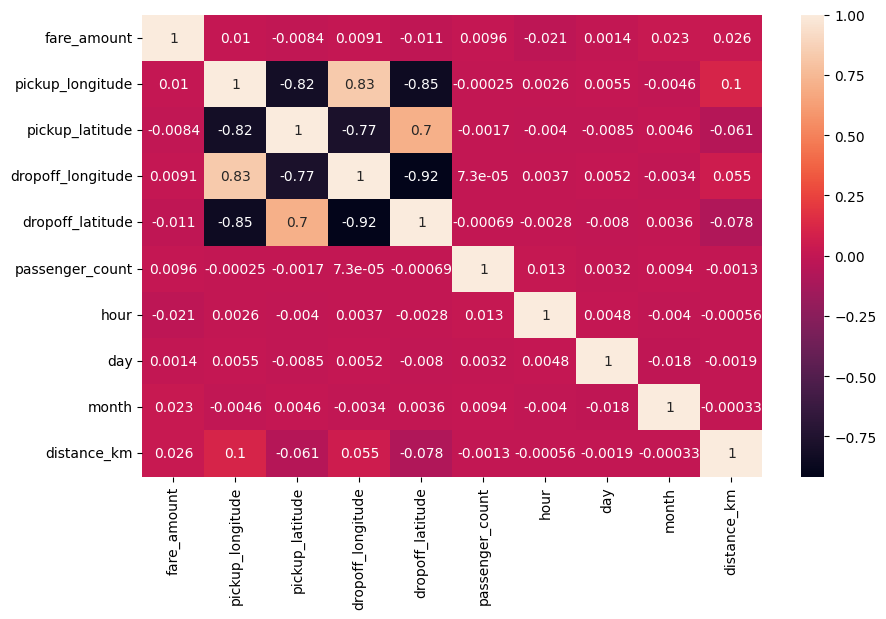

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop(columns=['Unnamed: 0', 'key', 'pickup_datetime']).corr(), annot=True)
plt.show()

**Feature Selection**

In [ ]:
X = df[['distance_km','passenger_count','hour','month']]
y = df['fare_amount']

**Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

**Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model 1 - **Linear Regression**

In [ ]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [ ]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 10.13303661991125
Linear Regression R2: 0.001494936830983673


# Model 2 - Random Forest

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 5.765352830984314
Random Forest R2: 0.6767616893503448


Compare Models

In [ ]:
results = pd.DataFrame({
    'Model':['Linear Regression','Random Forest'],
    'RMSE':[rmse_lr, rmse_rf],
    'R2 Score':[r2_lr, r2_rf]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,10.133037,0.001495
1,Random Forest,5.765353,0.676762


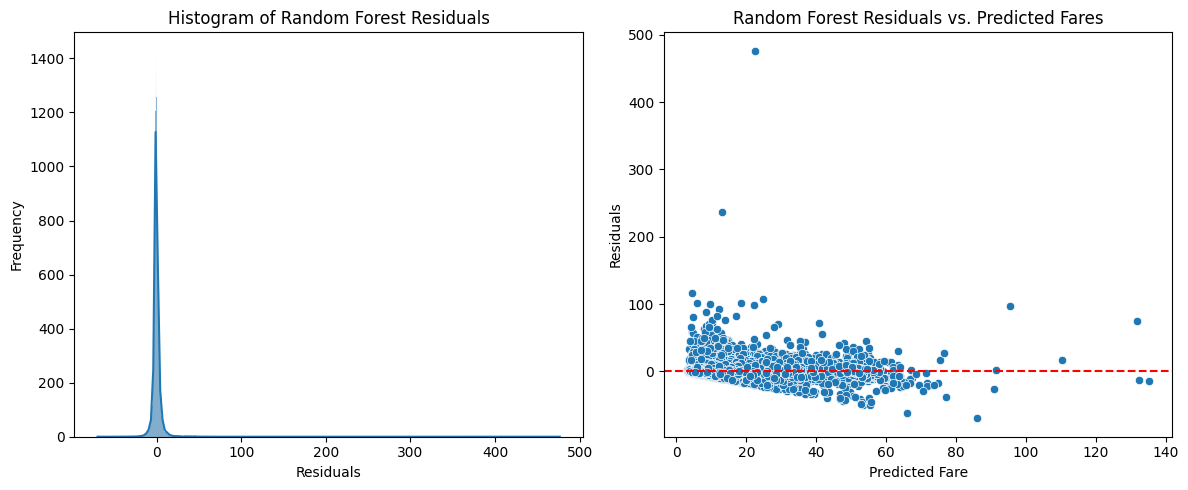

In [ ]:
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuals_rf, kde=True)
plt.title('Histogram of Random Forest Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_rf, y=residuals_rf)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Random Forest Residuals vs. Predicted Fares')
plt.xlabel('Predicted Fare')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

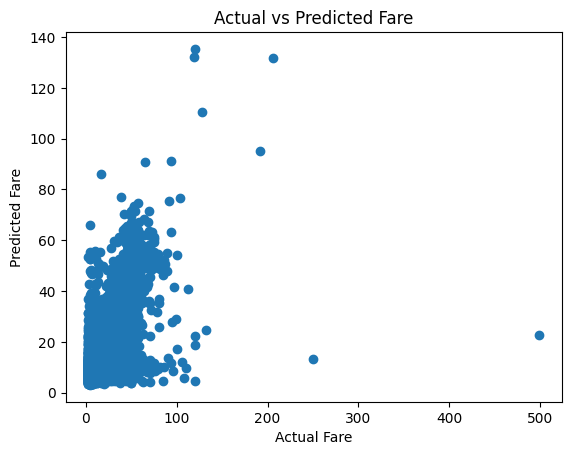

In [ ]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")
plt.show()

Random Forest achieved a lower RMSE and higher R² score compared to Linear Regression.
This indicates that Random Forest captures nonlinear relationships in the data better.
Therefore, Random Forest is the best model for predicting Uber fares in this project.